<a href="https://colab.research.google.com/github/DileepaLakshan/Stress-Level-Prediction-Model/blob/main/Stress_Level_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Stress Level Prediction,**
**Group 18,**
**KUMARA A.R.M.D.D. EG/2021/4622,**
**De Silva W.D.L. EG/2021/4468**


#**Introduction**

Stress has become a pervasive issue in modern society, significantly impacting physical and mental health. It is influenced by various factors, including sleep patterns, lifestyle habits, and overall health conditions. Prolonged stress can lead to severe health issues, such as cardiovascular diseases, mental health disorders, and weakened immunity. As a result, accurately predicting stress levels has garnered significant interest from researchers and healthcare providers. This project explores the use of machine learning techniques, specifically Linear Regression and Random Forest Regressor, to predict stress levels based on the Sleep Health and Lifestyle Dataset. The dataset includes a variety of features that capture the interplay between sleep, health, and lifestyle factors. By analyzing these features, this study aims to identify key contributors to stress and develop a robust predictive framework.

#**Literature Survey**

Many studies have examined the relationship between stress and lifestyle choices. Your stress levels are influenced by a number of factors, including your diet, physical activity level, and sleep patterns. For example, a study by Singh and colleagues (2020) found that stress levels can increase as a result of insufficient sleep and insufficient exercise.. According to a different study by Karasek and Theorell (1990), your workplace culture and the nature of your job can also make you more stressed. Advancements in machine learning have enabled researchers to analyze complex relationships between stress and its predictors. Studies like [Chandra et al. (2021)] demonstrate that regression models, such as Linear Regression and Random Forest, are effective in predicting stress levels based on biometric and lifestyle data.

# **Dataset Description**

Dataset: Sleep Health and Lifestyle Dataset (Ref: https://www.kaggle.com/datasets/uom190346a/sleep-health-and-lifestyle-dataset?resource=download)

Features:
> Gender: The gender of the person (Male/Female). <br>

> Age: The age of the person in years. <br>

> Occupation: The occupation or profession of the person. <br>

> Sleep Duration (hours): The number of hours the person sleeps per day. <br>

> Quality of Sleep (scale: 1-10): A subjective rating of the quality of sleep, ranging from 1 to 10. <br>

> Physical Activity Level (minutes/day): The number of minutes the person engages in physical activity daily. <br>

> BMI Category: The BMI category of the person (e.g., Underweight, Normal, Overweight). <br>

> Blood Pressure: The measure of the force of blood pushing against blood vessel walls.<br>

> Heart Rate: The number of heartbeats per minute (BPM).<br>

> Daily Steps: The number of steps the person takes per day. <br>

> Sleep Disorder: The presence or absence of a sleep disorder in the person (None, Insomnia, Sleep Apnea). <br>

> Stress Level (scale: 1-10): A subjective rating of the stress level experienced by the person, ranging from 1 to 10. <br>

>This model aims to predict a person's stress level (on a scale of 1 to 10) based on key features such as gender, age, occupation, sleep duration and quality, physical activity, BMI category, blood pressure, heart rate, daily steps, and the presence of sleep disorders. By analyzing these indicators, the model provides insights into stress levels, helping individuals and professionals better understand and manage stress in daily life.








#**Data Loading**

##**Libraries**

In [ ]:
# Import the necessary libaries

import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OrdinalEncoder

In [ ]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error,r2_score

## **Load data as a pandas dataframe**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:


df = pd.read_csv("/content/drive/MyDrive/ML Workshop/Sleep_health_and_lifestyle_dataset.csv")


df.head() #This function displays the first five rows of the DataFrame

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


# **Derived Feature Creation**

#**Exploratory Data Analysis**


In [ ]:
# Describe the charateristics of the numerical features in the training set
X_valtrain.describe()

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,BMI Category,Heart Rate,Daily Steps
count,280.000000,280.000000,280.000000,280.000000,280.000000,280.000000,280.000000,280.000000
mean,192.242857,42.539286,7.149643,7.353571,60.207143,1.321429,70.067857,6882.142857
std,105.861875,8.475469,0.786216,1.176223,20.844533,1.438178,4.073567,1600.235998
min,2.000000,28.000000,5.800000,4.000000,30.000000,0.000000,65.000000,3000.000000
25%,103.750000,36.000000,6.500000,6.000000,45.000000,0.000000,68.000000,6000.000000
50%,194.500000,43.000000,7.200000,7.000000,60.000000,0.000000,70.000000,7000.000000
75%,281.250000,50.000000,7.800000,8.000000,75.000000,3.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,3.000000,86.000000,10000.000000


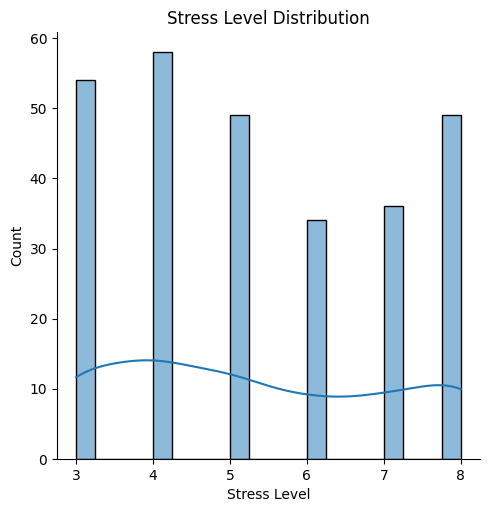

In [ ]:
# Check for the Stress Level distribution

sns.displot(y_valtrain, kde=True, bins = 20).set(title = "Stress Level Distribution");
# plt.show()

In [ ]:
# Check for the Gender distribution

sns.countplot(x = X_valtrain.Gender).set(title = 'Gender Distribution')
#plt.show()

AttributeError: 'DataFrame' object has no attribute 'Gender'

In [ ]:
# Check for the Occupation distribution between genders

sns.catplot(x="Occupation", kind="count", hue = 'Gender', data=X_valtrain, height=5, aspect=4).set(title="Occupation and  W.R.T Gender");

In [ ]:
# Check for the Stress Levelrges distribution for Occupation seperately
# But we have dropped the Stress Leveles column before, therefore, we need to concatenate them once again

df_temp_train = pd.concat([X_valtrain, y_valtrain], axis=1)
df_temp_train.head()

In [ ]:
# Initialize a figure with a specified size
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(10, 20))  # Adjust the number of rows and columns

occupations = [
    'Salesperson', 'Lawyer', 'Doctor', 'Engineer',
    'Nurse', 'Teacher', 'Scientist',
    'Software Engineer', 'Sales Representative', 'Manager'
]

# Loop through each occupation and create a histogram
for ax, occupation in zip(axes.flatten(), occupations):
    sns.histplot(df_temp_train[df_temp_train.Occupation == occupation]["Stress Level"], color='g', ax=ax)
    ax.set_title(f'Distribution of Stress Levels for {occupation}')
    ax.set_xlabel('Stress Level')  # Optional: Add labels for clarity
    ax.set_ylabel('Frequency')  # Optional: Add labels for clarity

# Adjust layout for better spacing
plt.tight_layout()
plt.show()  # Display the figure

Mounted at /content/drive

Split 'Blood Pressure' into 'Systolic' and 'Diastolic'

In [ ]:
df[['Systolic', 'Diastolic']] = df['Blood Pressure'].str.split('/', expand=True)

# Convert the 'Systolic' and 'Diastolic' columns to numeric values
df['Systolic'] = pd.to_numeric(df['Systolic'])
df['Diastolic'] = pd.to_numeric(df['Diastolic'])

# Drop the original 'Blood Pressure' column
df = df.drop(columns=['Blood Pressure'])

In [ ]:
df = df.drop(columns=["Person ID"])

In [ ]:
df.head()

In [ ]:
# Print the shape of the dataframe

df.shape

In [ ]:
# Print a concise summary of the pandas dataframe

df.info()

#**Data Preprocessing**

##**Train Test Split**

### Data separation as x and y

In [ ]:
# Seperate the independent and dependent variables
X = df.drop('Stress Level', axis=1) #axis=1 specifies that we are dropping a column (not a row).
y = df['Stress Level']

In [ ]:
# Display the first 5 data points

X.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,Obese,140/90,85,3000,Sleep Apnea


In [ ]:
# Diplay first five corresponding targets

y[:5]

,Stress Level
0,6
1,8
2,8
3,8
4,8


### Train test split

In [ ]:
X_valtrain, X_test, y_valtrain, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [ ]:
# Lenth of the training + validation sets
len(X_valtrain)

280

In [ ]:
# Length of the testing set
len(X_test)

94

##**Handling Null/Missing Values**

In [ ]:
X_valtrain.isnull().sum()

,0
Person ID,0
Gender,0
Age,0
Occupation,0
Sleep Duration,0
Quality of Sleep,0
Physical Activity Level,0
BMI Category,0
Blood Pressure,0
Heart Rate,0


"None" values, which may be mistakenly interpreted as null by the machine learning model.

In [ ]:
#Remove sleep Disorder column
# X_valtrain = X_valtrain.drop(['Sleep Disorder'], axis=1)


##Treating Duplicate Records

In [ ]:
X_valtrain.duplicated()

,0
222,False
227,False
141,False
17,False
246,False
...,...
71,False
106,False
270,False
348,False


Drop Duplicate Records

In [ ]:
# X_valtrain.drop_duplicates()

##Treating Outliers

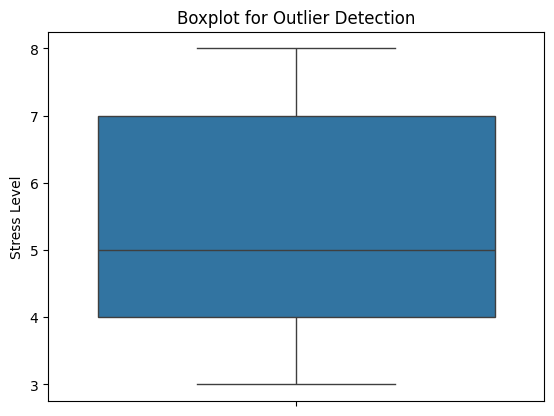

In [ ]:
sns.boxplot(data=X_valtrain, y=y_valtrain)
plt.title("Boxplot for Outlier Detection")
plt.show()

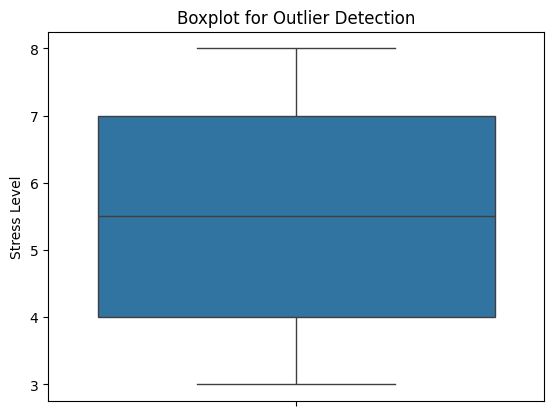

In [ ]:
sns.boxplot(data=X_test, y=y_test)
plt.title("Boxplot for Outlier Detection")
plt.show()

there are no outliers so we don't need to treat for this

##Handling Categorical Variables

### **For valitrain**

In [ ]:
X_valtrain.info()


<class 'pandas.core.frame.DataFrame'>
Index: 280 entries, 222 to 102
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                280 non-null    int64  
 1   Gender                   280 non-null    object 
 2   Age                      280 non-null    int64  
 3   Occupation               280 non-null    object 
 4   Sleep Duration           280 non-null    float64
 5   Quality of Sleep         280 non-null    int64  
 6   Physical Activity Level  280 non-null    int64  
 7   BMI Category             280 non-null    object 
 8   Blood Pressure           280 non-null    object 
 9   Heart Rate               280 non-null    int64  
 10  Daily Steps              280 non-null    int64  
 11  Sleep Disorder           116 non-null    object 
dtypes: float64(1), int64(6), object(5)
memory usage: 28.4+ KB


In [ ]:
X_valtrain.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
222,223,Male,44,Salesperson,6.3,6,45,Overweight,130/85,72,6000,Insomnia
227,228,Male,44,Salesperson,6.3,6,45,Overweight,130/85,72,6000,Insomnia
141,142,Male,38,Lawyer,7.1,8,60,Normal,130/85,68,8000,NaN
17,18,Male,29,Doctor,6.0,6,30,Normal,120/80,70,8000,Sleep Apnea
246,247,Male,44,Salesperson,6.3,6,45,Overweight,130/85,72,6000,Insomnia


In [ ]:
X_valtrain = pd.get_dummies(X_valtrain, columns=['Gender', 'Occupation','Sleep Disorder'])

In [ ]:
encoder = OrdinalEncoder()

categorical_columns = ['BMI Category']
# Initialize OrdinalEncoder
encoder = OrdinalEncoder()

# Fit and transform the categorical columns
X_valtrain[categorical_columns] = encoder.fit_transform(X_valtrain[categorical_columns])

In [ ]:
X_valtrain.info()

<class 'pandas.core.frame.DataFrame'>
Index: 280 entries, 222 to 102
Data columns (total 24 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Person ID                        280 non-null    int64  
 1   Age                              280 non-null    int64  
 2   Sleep Duration                   280 non-null    float64
 3   Quality of Sleep                 280 non-null    int64  
 4   Physical Activity Level          280 non-null    int64  
 5   BMI Category                     280 non-null    float64
 6   Blood Pressure                   280 non-null    object 
 7   Heart Rate                       280 non-null    int64  
 8   Daily Steps                      280 non-null    int64  
 9   Gender_Female                    280 non-null    bool   
 10  Gender_Male                      280 non-null    bool   
 11  Occupation_Accountant            280 non-null    bool   
 12  Occupation_Doctor        

In [ ]:
X_valtrain.head()

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Gender_Female,...,Occupation_Lawyer,Occupation_Manager,Occupation_Nurse,Occupation_Sales Representative,Occupation_Salesperson,Occupation_Scientist,Occupation_Software Engineer,Occupation_Teacher,Sleep Disorder_Insomnia,Sleep Disorder_Sleep Apnea
222,223,44,6.3,6,45,3.0,130/85,72,6000,False,...,False,False,False,False,True,False,False,False,True,False
227,228,44,6.3,6,45,3.0,130/85,72,6000,False,...,False,False,False,False,True,False,False,False,True,False
141,142,38,7.1,8,60,0.0,130/85,68,8000,False,...,True,False,False,False,False,False,False,False,False,False
17,18,29,6.0,6,30,0.0,120/80,70,8000,False,...,False,False,False,False,False,False,False,False,False,True
246,247,44,6.3,6,45,3.0,130/85,72,6000,False,...,False,False,False,False,True,False,False,False,True,False


### **For Test**

In [ ]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 94 entries, 329 to 322
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                94 non-null     int64  
 1   Gender                   94 non-null     object 
 2   Age                      94 non-null     int64  
 3   Occupation               94 non-null     object 
 4   Sleep Duration           94 non-null     float64
 5   Quality of Sleep         94 non-null     int64  
 6   Physical Activity Level  94 non-null     int64  
 7   BMI Category             94 non-null     object 
 8   Blood Pressure           94 non-null     object 
 9   Heart Rate               94 non-null     int64  
 10  Daily Steps              94 non-null     int64  
 11  Sleep Disorder           39 non-null     object 
dtypes: float64(1), int64(6), object(5)
memory usage: 9.5+ KB


In [ ]:
X_test.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
329,330,Female,53,Engineer,8.5,9,30,Normal,125/80,65,5000,NaN
33,34,Male,31,Doctor,6.1,6,30,Normal,125/80,72,5000,NaN
15,16,Male,29,Doctor,6.0,6,30,Normal,120/80,70,8000,NaN
325,326,Female,53,Engineer,8.5,9,30,Normal,125/80,65,5000,NaN
57,58,Male,32,Doctor,6.0,6,30,Normal,125/80,72,5000,NaN


In [ ]:
X_test = pd.get_dummies(X_test, columns=['Gender', 'Occupation','Sleep Disorder'])

In [ ]:

encoder = OrdinalEncoder()

categorical_columns = ['BMI Category']

# Initialize OrdinalEncoder
encoder = OrdinalEncoder()

# Fit and transform the categorical columns
X_test[categorical_columns] = encoder.fit_transform(X_test[categorical_columns])

In [ ]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 94 entries, 329 to 322
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Person ID                        94 non-null     int64  
 1   Age                              94 non-null     int64  
 2   Sleep Duration                   94 non-null     float64
 3   Quality of Sleep                 94 non-null     int64  
 4   Physical Activity Level          94 non-null     int64  
 5   BMI Category                     94 non-null     float64
 6   Blood Pressure                   94 non-null     object 
 7   Heart Rate                       94 non-null     int64  
 8   Daily Steps                      94 non-null     int64  
 9   Gender_Female                    94 non-null     bool   
 10  Gender_Male                      94 non-null     bool   
 11  Occupation_Accountant            94 non-null     bool   
 12  Occupation_Doctor         

In [ ]:
X_test.head()

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Gender_Female,...,Occupation_Doctor,Occupation_Engineer,Occupation_Lawyer,Occupation_Nurse,Occupation_Sales Representative,Occupation_Salesperson,Occupation_Software Engineer,Occupation_Teacher,Sleep Disorder_Insomnia,Sleep Disorder_Sleep Apnea
329,330,53,8.5,9,30,0.0,125/80,65,5000,True,...,False,True,False,False,False,False,False,False,False,False
33,34,31,6.1,6,30,0.0,125/80,72,5000,False,...,True,False,False,False,False,False,False,False,False,False
15,16,29,6.0,6,30,0.0,120/80,70,8000,False,...,True,False,False,False,False,False,False,False,False,False
325,326,53,8.5,9,30,0.0,125/80,65,5000,True,...,False,True,False,False,False,False,False,False,False,False
57,58,32,6.0,6,30,0.0,125/80,72,5000,False,...,True,False,False,False,False,False,False,False,False,False


##Feature Scaling

### **For Valitrain**

In [ ]:
scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(X_valtrain)

X_test_scaled = scaler.fit_transform(X_test)


X_valtrain = pd.DataFrame(X_train_scaled, columns=X_valtrain.columns)
X_test = pd.DataFrame(X_test_scaled, columns=X_test.columns)

ValueError: could not convert string to float: '130/85'

In [ ]:
X_valtrain.head()

### **For Test**

In [ ]:
X_test.head()

##Feature Selection

In [ ]:
corr = X_valtrain.corr()

# Visualize the correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

In [ ]:
correlation = X_valtrain.corrwith(y_valtrain)

# Print the correlation values
correlation

# You can also visualize the correlations using a heatmap if needed
# Create a DataFrame for the correlation to visualize it
corr_df = pd.DataFrame(correlation, columns=['Correlation'])

# Plot the correlation
plt.figure(figsize=(10, 6))
sns.heatmap(corr_df, annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

**'Physical Activity Level','BMI Category', 'Daily Steps','Occupation_Manager','Occupation_Software Engineer','Occupation_Scientist' have small relationship between with target variable**

In [ ]:
# Remove Some column
X_valtrain = X_valtrain.drop([ 'Physical Activity Level','BMI Category', 'Daily Steps','Occupation_Manager','Occupation_Software Engineer','Occupation_Scientist'], axis=1)
X_valtrain.head()

In [ ]:
X_test = X_test.drop(['Physical Activity Level','BMI Category', 'Daily Steps','Occupation_Software Engineer'], axis=1)
X_test.head()

#ML Model Implementation & Evaluation

## Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression

reg = LinearRegression() #create LinearRegression but not trained

In [ ]:
reg.fit(X_valtrain, y_valtrain) # Training the Model

ValueError: could not convert string to float: '130/85'

In [ ]:
reg.score(X_valtrain, y_valtrain) # Evaluating the Model’s Performance on training set

A score of 1.0 indicates a perfect fit, while a score closer to 0 indicates a weak relationship between the features and the target variable.

In [ ]:
reg.score(X_test, y_test) # Evaluating the Model’s Performance on test trainng set

In [ ]:
# Model Evaluation

y_valtrain_preds = reg.predict(X_valtrain)
y_test_preds = reg.predict(X_test)

In [ ]:
# R2 Error
print("R2 Error (Train set): ", r2_score(y_valtrain, y_valtrain_preds))
print("R2 Error (Test set): ", r2_score(y_test, y_test_preds))

In [ ]:
# Mean Squred Error
print("Mean Squred Error (Train set): ", mean_squared_error(y_valtrain, y_valtrain_preds))
print("Mean Squred Error (Test set): ", mean_squared_error(y_test, y_test_preds))

##Random Forest Regressor

In [ ]:
rfr = RandomForestRegressor(random_state=42) #create Random Forest Regressor model but not trained
rfr.fit(X_valtrain, y_valtrain) # Training the Model

In [ ]:
rfr.score(X_valtrain, y_valtrain) # Evaluating the Model’s Performance on training set

In [ ]:
rfr.score(X_test, y_test) # Evaluating the Model’s Performance on training set

In [ ]:
# Model Evaluation

y_valtrain_preds = rfr.predict(X_valtrain)
y_test_preds = rfr.predict(X_test)

In [ ]:
# R2 Error
print("R2 Error (Train set): ", r2_score(y_valtrain, y_valtrain_preds))
print("R2 Error (Test set): ", r2_score(y_test, y_test_preds))

In [ ]:
# Mean Squred Error
print("Mean Squred Error (Train set): ", mean_squared_error(y_valtrain, y_valtrain_preds))
print("Mean Squred Error (Test set): ", mean_squared_error(y_test, y_test_preds))

#**Conclusion**

In this project, we applied two machine learning models, Linear Regression and Random Forest, to analyze a dataset. Despite the dataset's size constraints, both models exhibited strong performance.

- **Linear Regression** achieved a training accuracy of 93.36% and a test accuracy of 93.85%, indicating good generalization ability and robust predictions.
- **Random Forest** showed superior performance with a training accuracy of 99.6% and a test accuracy of 99.0%, demonstrating its capacity to capture complex patterns in the data.

The high accuracy of both models validates the effectiveness of the selected features and preprocessing steps. However, the small dataset size could limit the generalizability of the models in real-world applications. To further enhance reliability and predictive power, future work should consider using a larger dataset and exploring additional feature engineering techniques.

These results underline the potential of machine learning techniques for solving similar problems, with Random Forest being particularly suitable for capturing non-linear relationships in the data.

#**References**

[1] 	"scikit-learn," 2009. [Online]. Available: https://scikit-learn.org/stable/modules/linear_model.html.

[2] 	E. R. Sruthi, "analyticsvidhya," 11 Dec 2021. [Online]. Available: https://www.analyticsvidhya.com/blog/2021/06/understanding-random-forest/.